<h1> <b style="color:green"> MACHINE LEARNING</b></h1>
<h2><b style="color:red"> Feature Engineering et préparation des données pour le Machine Learning ! 🚀 </b></h2>

<p><b style="color:blue">Le Feature Engineering !</b> C'est l'art de transformer les données brutes en variables que les algorithmes <br> de Machine Learning peuvent comprendre et exploiter.</p>

<h2><b>🎯 Objectif du jour</b></h2>
<p>Maîtriser les techniques de préparation des données pour le Machine Learning — encodage, normalisation, création de variables et sélection de features.</p>

<h3> Encodage des variables catégorielles.</h3>

<h4> Setup et dataset :</h4>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import (LabelEncoder, OneHotEncoder, 
                                   StandardScaler, MinMaxScaler,
                                   RobustScaler)
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
np.random.seed(42)

# Dataset : clients d'une banque camerounaise
n = 500
df = pd.DataFrame({
    "age": np.random.randint(18, 65, n),
    "salaire": np.random.normal(350000, 150000, n).astype(int).clip(50000),
    "experience": np.random.randint(0, 35, n),
    "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam", "Garoua"], n),
    "education": np.random.choice(["Bac", "Licence", "Master", "Doctorat"], n),
    "type_contrat": np.random.choice(["CDI", "CDD", "Freelance"], n),
    "nb_produits": np.random.randint(1, 6, n),
    "solde": np.random.normal(500000, 300000, n).astype(int).clip(0),
    "actif": np.random.choice([0, 1], n, p=[0.3, 0.7]),
    "churn": np.random.choice([0, 1], n, p=[0.75, 0.25])  # cible
})

print("=== APERÇU DU DATASET ===")
print(df.head())
print(f"\nShape : {df.shape}")
print(f"\nTypes :\n{df.dtypes}")

=== APERÇU DU DATASET ===
   age  salaire  experience      ville education type_contrat  nb_produits  \
0   56   669955          20  Bafoussam   Licence    Freelance            2   
1   46    57186          16     Garoua  Doctorat    Freelance            3   
2   32   327232          22    Yaoundé    Master    Freelance            1   
3   60   438247          15     Douala    Master          CDD            1   
4   25   392148           5     Garoua    Master    Freelance            5   

    solde  actif  churn  
0  423530      1      0  
1  633084      1      0  
2  685109      0      0  
3  610216      1      0  
4  467267      1      1  

Shape : (500, 10)

Types :
age             int32
salaire         int64
experience      int32
ville             str
education         str
type_contrat      str
nb_produits     int32
solde           int64
actif           int64
churn           int64
dtype: object


<p><h4>💡 Pourquoi le Feature Engineering ?</h4>
Les algorithmes de Machine Learning ne comprennent que les nombres — ils ne peuvent pas traiter du texte comme "Douala" ou "CDI".<br> Le Feature Engineering transforme ces données en nombres exploitables !</p>

<h4> Label Encoding :</h4>

In [2]:
# Label Encoding — transformer les catégories en nombres
# Adapté pour les variables ORDINALES (qui ont un ordre naturel)

df_encode = df.copy()

# Exemple : éducation a un ordre naturel Bac < Licence < Master < Doctorat
label_encoder = LabelEncoder()

# Encodage automatique (ordre alphabétique — pas toujours bon !)
df_encode["education_auto"] = label_encoder.fit_transform(df["education"])
print("=== LABEL ENCODING AUTOMATIQUE ===")
print(df_encode[["education", "education_auto"]].drop_duplicates().sort_values("education_auto"))

# Encodage manuel — on définit l'ordre nous-mêmes ✅
ordre_education = {"Bac": 0, "Licence": 1, "Master": 2, "Doctorat": 3}
df_encode["education_ordinal"] = df["education"].map(ordre_education)
print("\n=== LABEL ENCODING MANUEL (ordre correct) ===")
print(df_encode[["education", "education_ordinal"]].drop_duplicates().sort_values("education_ordinal"))

# Même chose pour le type de contrat
ordre_contrat = {"CDD": 0, "CDI": 1, "Freelance": 2}
df_encode["contrat_ordinal"] = df["type_contrat"].map(ordre_contrat)
print("\n=== CONTRAT ENCODÉ ===")
print(df_encode[["type_contrat", "contrat_ordinal"]].drop_duplicates())

=== LABEL ENCODING AUTOMATIQUE ===
  education  education_auto
6       Bac               0
1  Doctorat               1
0   Licence               2
2    Master               3

=== LABEL ENCODING MANUEL (ordre correct) ===
  education  education_ordinal
6       Bac                  0
0   Licence                  1
2    Master                  2
1  Doctorat                  3

=== CONTRAT ENCODÉ ===
  type_contrat  contrat_ordinal
0    Freelance                2
3          CDD                0
8          CDI                1


<h4>💡 Label Encoding automatique vs manuel :</h4>
<ul><li>
Automatique → ordre alphabétique — Bac=0, Doctorat=1, Licence=2, Master=3 ❌ pas logique !</li>
<li>Manuel → tu définis l'ordre toi-même — Bac=0, Licence=1, Master=2, Doctorat=3 ✅</li>
  </ul>
Toujours utiliser l'encodage manuel pour les variables ordinales !

<h4>One-Hot Encoding :</h4>

In [3]:
# One-Hot Encoding — créer une colonne binaire par catégorie
# Adapté pour les variables NOMINALES (sans ordre naturel)
# Exemple : ville n'a pas d'ordre — Douala n'est pas "plus grand" que Yaoundé

# Méthode 1 : avec pandas get_dummies
dummies_ville = pd.get_dummies(df["ville"], prefix="ville")
print("=== ONE-HOT ENCODING — VILLE ===")
print(dummies_ville.head(8))

# Ajouter au DataFrame
df_encode = pd.concat([df_encode, dummies_ville], axis=1)
print(f"\nNouvelles colonnes : {dummies_ville.columns.tolist()}")

# Méthode 2 : avec sklearn OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop="first")  
# drop="first" évite la multicolinéarité !
ville_encoded = encoder.fit_transform(df[["ville"]])
print("\n=== ONE-HOT ENCODING SKLEARN ===")
print(f"Shape : {ville_encoded.shape}")
print(f"Catégories : {encoder.categories_}")

# Pourquoi drop="first" ?
print("\n=== EXPLICATION drop='first' ===")
print("Sans drop : 4 colonnes (Bafoussam, Douala, Garoua, Yaoundé)")
print("Avec drop : 3 colonnes (Douala, Garoua, Yaoundé)")
print("Si les 3 autres = 0 → c'est forcément Bafoussam !")
print("La 4ème colonne est donc redondante — on la supprime !")

=== ONE-HOT ENCODING — VILLE ===
   ville_Bafoussam  ville_Douala  ville_Garoua  ville_Yaoundé
0             True         False         False          False
1            False         False          True          False
2            False         False         False           True
3            False          True         False          False
4            False         False          True          False
5            False          True         False          False
6            False          True         False          False
7            False         False         False           True

Nouvelles colonnes : ['ville_Bafoussam', 'ville_Douala', 'ville_Garoua', 'ville_Yaoundé']

=== ONE-HOT ENCODING SKLEARN ===
Shape : (500, 3)
Catégories : [array(['Bafoussam', 'Douala', 'Garoua', 'Yaoundé'], dtype=object)]

=== EXPLICATION drop='first' ===
Sans drop : 4 colonnes (Bafoussam, Douala, Garoua, Yaoundé)
Avec drop : 3 colonnes (Douala, Garoua, Yaoundé)
Si les 3 autres = 0 → c'est forcément Bafou

<p><h4>💡 Résumé des points clés : </h4>
<ul>
<li>df.copy() → toujours travailler sur une copie pour préserver les données originales </li>
<li>map(dictionnaire) → remplace les valeurs selon un dictionnaire — très pratique pour l'encodage ordinal</li>
<li>pd.get_dummies() → One-Hot Encoding rapide avec Pandas</li>
<li>drop="first" → évite la multicolinéarité — si tu as 4 villes et que 3 sont à 0, la 4ème est forcément 1 !</li></ul></p>

<h3>Normalisation et standardisation !</h3>

<h2> Les 3 scalers essentiels :</h2>

In [4]:
# Les algorithmes ML sont sensibles à l'échelle des variables !
# Exemple : salaire (350 000) vs nb_produits (1-5) → le salaire domine injustement

# Sélectionner les variables numériques à normaliser
variables_num = ["age", "salaire", "experience", "solde", "nb_produits"]
X = df[variables_num].copy()

print("=== AVANT NORMALISATION ===")
print(X.describe().round(0))

# ----------------------------------------
# 1. StandardScaler — Standardisation Z-score
# Formule : (x - moyenne) / écart-type
# Résultat : moyenne=0, écart-type=1
# Quand utiliser : données normalement distribuées
# ----------------------------------------
scaler_standard = StandardScaler()
X_standard = pd.DataFrame(
    scaler_standard.fit_transform(X),
    columns=[f"{col}_std" for col in variables_num]
)
print("\n=== APRÈS STANDARDISATION (Z-score) ===")
print(X_standard.describe().round(3))

# ----------------------------------------
# 2. MinMaxScaler — Normalisation Min-Max
# Formule : (x - min) / (max - min)
# Résultat : toutes les valeurs entre 0 et 1
# Quand utiliser : réseaux de neurones, KNN
# ----------------------------------------
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(X),
    columns=[f"{col}_mm" for col in variables_num]
)
print("\n=== APRÈS NORMALISATION MIN-MAX ===")
print(X_minmax.describe().round(3))

# ----------------------------------------
# 3. RobustScaler — Robuste aux outliers
# Formule : (x - médiane) / IQR
# Résultat : centré sur la médiane
# Quand utiliser : données avec beaucoup d'outliers
# ----------------------------------------
scaler_robust = RobustScaler()
X_robust = pd.DataFrame(
    scaler_robust.fit_transform(X),
    columns=[f"{col}_rob" for col in variables_num]
)
print("\n=== APRÈS ROBUST SCALING ===")
print(X_robust.describe().round(3))

=== AVANT NORMALISATION ===
         age   salaire  experience      solde  nb_produits
count  500.0     500.0       500.0      500.0        500.0
mean    41.0  349623.0        17.0   515617.0          3.0
std     13.0  146267.0        10.0   287263.0          1.0
min     18.0   50000.0         0.0        0.0          1.0
25%     30.0  244912.0         9.0   298967.0          2.0
50%     42.0  347185.0        17.0   514684.0          3.0
75%     52.0  444548.0        27.0   720496.0          4.0
max     64.0  811832.0        34.0  1548763.0          5.0

=== APRÈS STANDARDISATION (Z-score) ===
       age_std  salaire_std  experience_std  solde_std  nb_produits_std
count  500.000      500.000         500.000    500.000          500.000
mean     0.000        0.000           0.000     -0.000           -0.000
std      1.001        1.001           1.001      1.001            1.001
min     -1.740       -2.051          -1.729     -1.797           -1.426
25%     -0.843       -0.717          -0.

| Algorithme | Sensible à l'échelle ? |
|------------|----------------------|
| **KNN** | ✅ Oui — calcule des distances |
| **SVM** | ✅ Oui — calcule des marges |
| **Régression linéaire** | ✅ Oui — coefficients biaisés |
| **Réseaux de neurones** | ✅ Oui — gradient instable |
| **Random Forest** | ❌ Non — basé sur des seuils |
| **XGBoost** | ❌ Non — basé sur des seuils |

<h4><b>Visualiser l'effet de la normalisation :</b></h4>

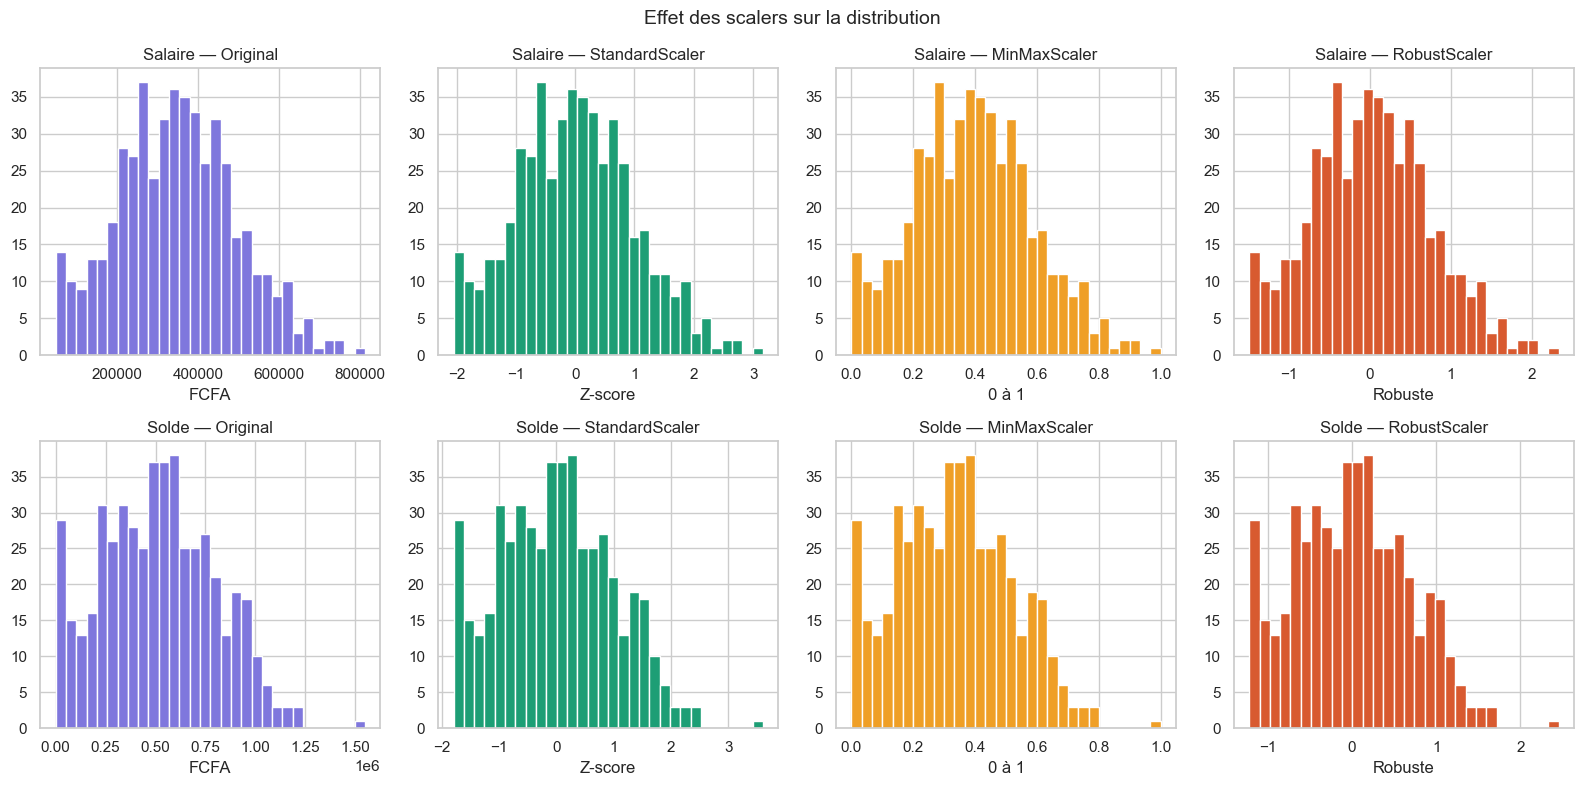

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Variable à visualiser : salaire
variable = "salaire"

# Données originales
axes[0,0].hist(df[variable], bins=30, color="#7F77DD", edgecolor="white")
axes[0,0].set_title("Salaire — Original")
axes[0,0].set_xlabel("FCFA")

# Après StandardScaler
axes[0,1].hist(X_standard[f"{variable}_std"], bins=30, 
               color="#1D9E75", edgecolor="white")
axes[0,1].set_title("Salaire — StandardScaler")
axes[0,1].set_xlabel("Z-score")

# Après MinMaxScaler
axes[0,2].hist(X_minmax[f"{variable}_mm"], bins=30,
               color="#EF9F27", edgecolor="white")
axes[0,2].set_title("Salaire — MinMaxScaler")
axes[0,2].set_xlabel("0 à 1")

# Après RobustScaler
axes[0,3].hist(X_robust[f"{variable}_rob"], bins=30,
               color="#D85A30", edgecolor="white")
axes[0,3].set_title("Salaire — RobustScaler")
axes[0,3].set_xlabel("Robuste")

# Variable à visualiser : solde
variable2 = "solde"

axes[1,0].hist(df[variable2], bins=30, color="#7F77DD", edgecolor="white")
axes[1,0].set_title("Solde — Original")
axes[1,0].set_xlabel("FCFA")

axes[1,1].hist(X_standard[f"{variable2}_std"], bins=30,
               color="#1D9E75", edgecolor="white")
axes[1,1].set_title("Solde — StandardScaler")
axes[1,1].set_xlabel("Z-score")

axes[1,2].hist(X_minmax[f"{variable2}_mm"], bins=30,
               color="#EF9F27", edgecolor="white")
axes[1,2].set_title("Solde — MinMaxScaler")
axes[1,2].set_xlabel("0 à 1")

axes[1,3].hist(X_robust[f"{variable2}_rob"], bins=30,
               color="#D85A30", edgecolor="white")
axes[1,3].set_title("Solde — RobustScaler")
axes[1,3].set_xlabel("Robuste")

plt.suptitle("Effet des scalers sur la distribution", fontsize=14)
plt.tight_layout()
plt.show()

<P><h4>💡 Ce que tu vas observer :</h4>
<ul><li>
La forme de la distribution ne change pas — StandardScaler ne rend pas une distribution non normale en normale !</li>
<li>Seule l'échelle change — les valeurs sont ramenées dans une plage comparable</li>
<li>RobustScaler est moins affecté par les valeurs extrêmes que StandardScaler</li></ul></P>

<h3>Création de features et sélection !</h3>

<h4>Création de nouvelles features :</h4>

In [6]:
df_feat = df.copy()

# 1. Features mathématiques
# Ratio salaire/expérience — mesure la progression salariale
df_feat["salaire_par_annee"] = (df_feat["salaire"] / 
                                 (df_feat["experience"] + 1)).round(0)

# Ratio solde/salaire — mesure la capacité d'épargne
df_feat["taux_epargne"] = (df_feat["solde"] / 
                            df_feat["salaire"]).round(3)

# Interaction age * expérience
df_feat["age_experience"] = df_feat["age"] * df_feat["experience"]

print("=== FEATURES MATHÉMATIQUES ===")
print(df_feat[["age", "salaire", "experience", "solde",
               "salaire_par_annee", "taux_epargne", 
               "age_experience"]].head())

# 2. Features temporelles — à partir de l'âge
df_feat["generation"] = pd.cut(
    df_feat["age"],
    bins=[0, 25, 35, 50, 100],
    labels=["Gen Z", "Millennial", "Gen X", "Boomer"]
)
print("\n=== GÉNÉRATION PAR ÂGE ===")
print(df_feat["generation"].value_counts())

# 3. Features binaires
df_feat["haut_salaire"] = (df_feat["salaire"] > 
                            df_feat["salaire"].median()).astype(int)
df_feat["client_fidele"] = (df_feat["experience"] > 10).astype(int)
df_feat["multi_produits"] = (df_feat["nb_produits"] > 3).astype(int)

print("\n=== FEATURES BINAIRES ===")
print(df_feat[["salaire", "haut_salaire", 
               "experience", "client_fidele",
               "nb_produits", "multi_produits"]].head(8))

# 4. Features de groupes — statistiques par ville
stats_ville = df_feat.groupby("ville")["salaire"].agg([
    "mean", "std"
]).rename(columns={"mean": "salaire_moy_ville", 
                   "std": "salaire_std_ville"})

df_feat = df_feat.merge(stats_ville, on="ville", how="left")
df_feat["salaire_vs_ville"] = (df_feat["salaire"] - 
                                df_feat["salaire_moy_ville"]) / \
                                df_feat["salaire_std_ville"]

print("\n=== FEATURES DE GROUPES ===")
print(df_feat[["ville", "salaire", "salaire_moy_ville", 
               "salaire_vs_ville"]].head(8))

=== FEATURES MATHÉMATIQUES ===
   age  salaire  experience   solde  salaire_par_annee  taux_epargne  \
0   56   669955          20  423530            31903.0         0.632   
1   46    57186          16  633084             3364.0        11.071   
2   32   327232          22  685109            14227.0         2.094   
3   60   438247          15  610216            27390.0         1.392   
4   25   392148           5  467267            65358.0         1.192   

   age_experience  
0            1120  
1             736  
2             704  
3             900  
4             125  

=== GÉNÉRATION PAR ÂGE ===
generation
Gen X         183
Boomer        143
Gen Z          90
Millennial     84
Name: count, dtype: int64

=== FEATURES BINAIRES ===
   salaire  haut_salaire  experience  client_fidele  nb_produits  \
0   669955             1          20              1            2   
1    57186             0          16              1            3   
2   327232             0          22            

<p><h4>💡 Les 4 types de features à créer :</h4>
<ul>
<li>Mathématiques → ratios, produits, différences entre variables</li>
<li>Temporelles → tranches d'âge, saisons, jours de semaine</li>
<li>Binaires → seuils (haut/bas, fidèle/nouveau)</li>
<li>Groupes → statistiques par catégorie (salaire moyen de la ville)</ul></p>

<h4>Sélection de features :</h4>

Features disponibles : 16
Shape X : (500, 16)

=== SELECTKBEST — TOP FEATURES ===
          feature    score  p_value
      contrat_enc 3.348045 0.067883
    client_fidele 1.545594 0.214372
            solde 1.375669 0.241401
    education_enc 1.131896 0.287887
       experience 0.758288 0.384285
        ville_enc 0.605591 0.436822
     haut_salaire 0.526791 0.468300
              age 0.478013 0.489646
salaire_par_annee 0.452001 0.501698
   generation_enc 0.374454 0.540866

=== RANDOM FOREST — IMPORTANCE DES FEATURES ===
          feature  importance
          salaire    0.126023
     taux_epargne    0.123830
            solde    0.115943
salaire_par_annee    0.114378
   age_experience    0.109049
              age    0.098446
       experience    0.086738
        ville_enc    0.040023
      nb_produits    0.039839
      contrat_enc    0.038832


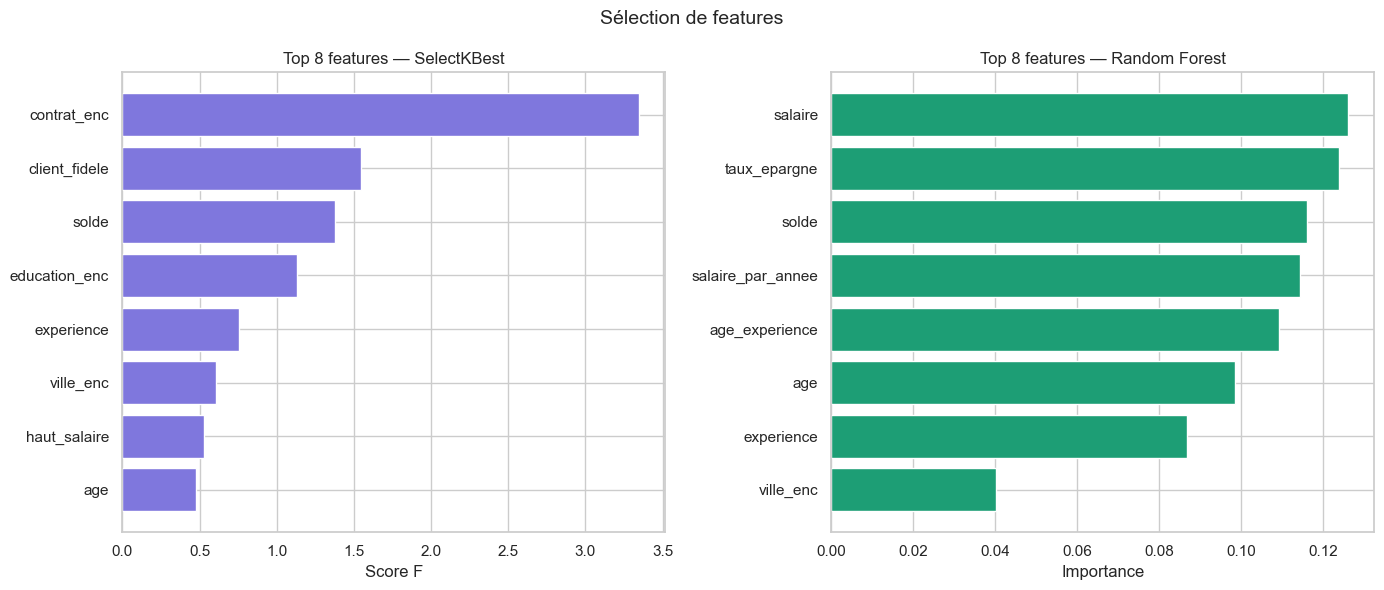

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

# Préparer les données pour la sélection
# On encode d'abord toutes les variables catégorielles
df_selection = df_feat.copy()

# Encoder les variables catégorielles restantes
df_selection["ville_enc"] = LabelEncoder().fit_transform(df_selection["ville"])
df_selection["education_enc"] = df_selection["education"].map(
    {"Bac": 0, "Licence": 1, "Master": 2, "Doctorat": 3})
df_selection["contrat_enc"] = df_selection["type_contrat"].map(
    {"CDD": 0, "CDI": 1, "Freelance": 2})
df_selection["generation_enc"] = df_selection["generation"].map(
    {"Gen Z": 0, "Millennial": 1, "Gen X": 2, "Boomer": 3})

# Sélectionner les features numériques
features = ["age", "salaire", "experience", "solde", "nb_produits",
            "actif", "salaire_par_annee", "taux_epargne",
            "haut_salaire", "client_fidele", "multi_produits",
            "ville_enc", "education_enc", "contrat_enc",
            "generation_enc", "age_experience"]

X = df_selection[features].fillna(0)
y = df_selection["churn"]

print(f"Features disponibles : {len(features)}")
print(f"Shape X : {X.shape}")

# ----------------------------------------
# Méthode 1 : SelectKBest — test statistique
# ----------------------------------------
selector = SelectKBest(score_func=f_classif, k=8)
selector.fit(X, y)

scores = pd.DataFrame({
    "feature": features,
    "score": selector.scores_,
    "p_value": selector.pvalues_
}).sort_values("score", ascending=False)

print("\n=== SELECTKBEST — TOP FEATURES ===")
print(scores.head(10).to_string(index=False))

# ----------------------------------------
# Méthode 2 : Random Forest — importance des features
# ----------------------------------------
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_rf = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== RANDOM FOREST — IMPORTANCE DES FEATURES ===")
print(importance_rf.head(10).to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SelectKBest
axes[0].barh(scores.head(8)["feature"][::-1],
             scores.head(8)["score"][::-1],
             color="#7F77DD")
axes[0].set_title("Top 8 features — SelectKBest")
axes[0].set_xlabel("Score F")

# Random Forest
axes[1].barh(importance_rf.head(8)["feature"][::-1],
             importance_rf.head(8)["importance"][::-1],
             color="#1D9E75")
axes[1].set_title("Top 8 features — Random Forest")
axes[1].set_xlabel("Importance")

plt.suptitle("Sélection de features", fontsize=14)
plt.tight_layout()
plt.show()

<p><h4>💡 Deux méthodes de sélection de features :</h4>
<ul><li>
SelectKBest → teste statistiquement la relation entre chaque feature et la cible — rapide mais univarié</li>
<li>Random Forest → mesure l'importance de chaque feature dans un modèle complet — plus puissant car tient compte des interactions !</li></ul></p>

<h1>Exercice pratique ! 💪</h1>

<p><b>Contexte :</b> Tu es data scientist dans une compagnie d'assurance camerounaise. Tu dois préparer les données pour prédire si un client va renouveler son contrat.</p>

1. **Encodage :**

   - LabelEncoding ordinal pour `satisfaction` (1→5)
   - One-Hot Encoding pour `type_contrat` et `ville`
   - LabelEncoding pour `sexe` (M=0, F=1)

2. **Normalisation :**

   - StandardScaler sur `prime_annuelle` et `montant_sinistres`
   - MinMaxScaler sur `age` et `anciennete`

3. **Création de features :**

   - `cout_par_annee = montant_sinistres / anciennete`
   - `ratio_sinistres = nb_sinistres / nb_produits`
   - `client_fidele = 1 si anciennete > 10 ans`
   - `segment_age` : Jeune (<30), Adulte (30-50), Senior (>50)

4. **Sélection de features :**

   - SelectKBest — top 6 features
   - Random Forest — top 6 features
   - Visualise les deux avec un graphique

=== SATISFACTION (déjà numérique) ===
satisfaction
1    109
2    135
3    102
4    128
5    126
Name: count, dtype: int64

=== SEXE ENCODÉ ===
  sexe  sexe_enc
0    F         1
3    M         0

=== ONE-HOT ENCODING — TYPE CONTRAT ===
   contrat_Auto  contrat_Habitation  contrat_Santé  contrat_Vie
0         False               False           True        False
1         False               False          False         True
2         False               False           True        False
3         False               False          False         True
4          True               False          False        False

=== ONE-HOT ENCODING — VILLE ===
   ville_Bafoussam  ville_Douala  ville_Garoua  ville_Yaoundé
0            False         False         False           True
1            False         False          True          False
2            False         False         False           True
3            False          True         False          False
4             True         False     

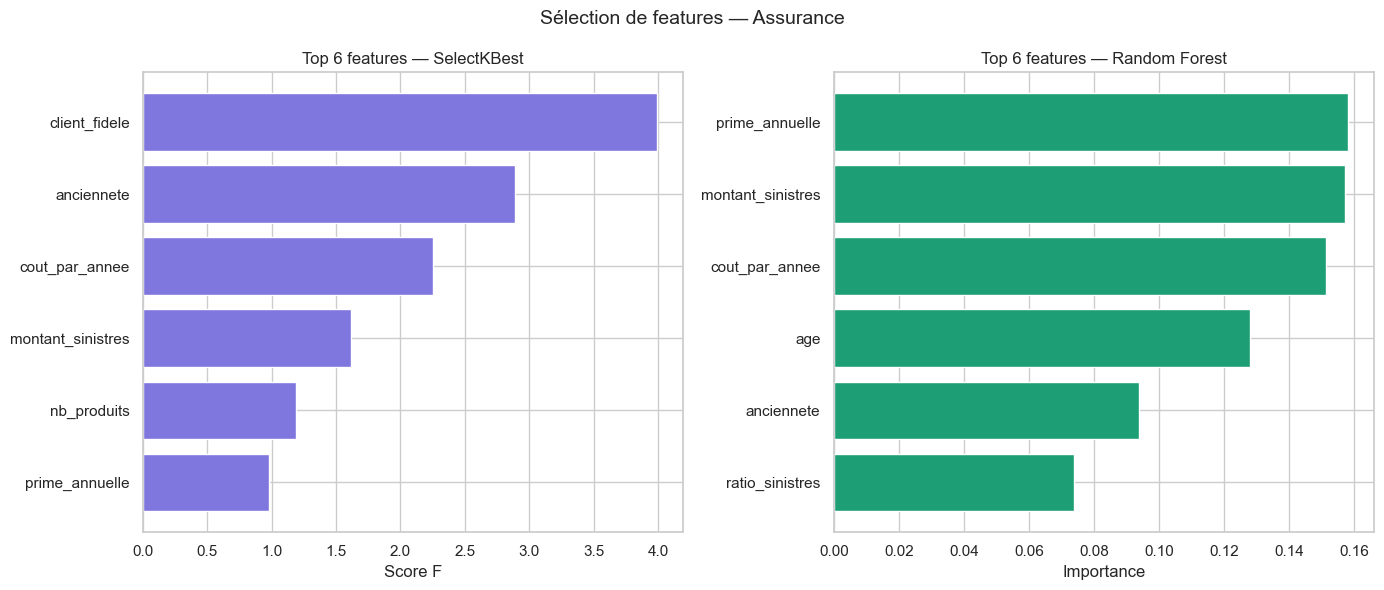

In [9]:
# ============================================================
# DATASET
# ============================================================
np.random.seed(42)
n = 600

df_assurance = pd.DataFrame({
    "client_id": range(1, n+1),
    "age": np.random.randint(20, 70, n),
    "sexe": np.random.choice(["M", "F"], n),
    "ville": np.random.choice(["Douala", "Yaoundé", "Bafoussam", "Garoua"], n),
    "type_contrat": np.random.choice(["Auto", "Habitation", "Vie", "Santé"], n),
    "anciennete": np.random.randint(1, 20, n),
    "prime_annuelle": np.random.normal(250000, 100000, n).astype(int).clip(50000),
    "nb_sinistres": np.random.poisson(1.5, n),
    "montant_sinistres": np.random.exponential(150000, n).astype(int),
    "nb_produits": np.random.randint(1, 5, n),
    "satisfaction": np.random.randint(1, 6, n),
    "renouvellement": np.random.choice([0, 1], n, p=[0.3, 0.7])
})

# ============================================================
# 1. ENCODAGE
# ============================================================
df_encode = df_assurance.copy()  # on travaille sur une copie

# Label Encoding ordinal pour satisfaction (déjà numérique 1→5, pas besoin)
print("=== SATISFACTION (déjà numérique) ===")
print(df_encode["satisfaction"].value_counts().sort_index())

# Label Encoding pour sexe (M=0, F=1)
ordre_sexe = {"M": 0, "F": 1}
df_encode["sexe_enc"] = df_encode["sexe"].map(ordre_sexe)  # ✅ df_encode
print("\n=== SEXE ENCODÉ ===")
print(df_encode[["sexe", "sexe_enc"]].drop_duplicates())

# One-Hot Encoding pour type_contrat
dummies_contrat = pd.get_dummies(
    df_encode["type_contrat"], prefix="contrat")  # ✅ df_encode
df_encode = pd.concat([df_encode, dummies_contrat], axis=1)
print("\n=== ONE-HOT ENCODING — TYPE CONTRAT ===")
print(dummies_contrat.head(5))

# One-Hot Encoding pour ville
dummies_ville = pd.get_dummies(
    df_encode["ville"], prefix="ville")  # ✅ df_encode
df_encode = pd.concat([df_encode, dummies_ville], axis=1)
print("\n=== ONE-HOT ENCODING — VILLE ===")
print(dummies_ville.head(5))

# ============================================================
# 2. NORMALISATION
# ============================================================
print("\n=== STANDARDSCALER — prime_annuelle et montant_sinistres ===")
variables_std = ["prime_annuelle", "montant_sinistres"]
X_std = df_assurance[variables_std].copy()
scaler_standard = StandardScaler()
X_standard = pd.DataFrame(
    scaler_standard.fit_transform(X_std),
    columns=[f"{col}_std" for col in variables_std]
)
print(X_standard.describe().round(3))

print("\n=== MINMAXSCALER — age et anciennete ===")
variables_mm = ["age", "anciennete"]
X_mm = df_assurance[variables_mm].copy()
scaler_minmax = MinMaxScaler()
X_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(X_mm),
    columns=[f"{col}_mm" for col in variables_mm]
)
print(X_minmax.describe().round(3))

# ============================================================
# 3. CRÉATION DE FEATURES
# ============================================================
df_feat = df_encode.copy()

# Feature 1 : coût moyen par année d'ancienneté
df_feat["cout_par_annee"] = (
    df_feat["montant_sinistres"] / df_feat["anciennete"]).round(0)

# Feature 2 : ratio sinistres par produit
df_feat["ratio_sinistres"] = (
    df_feat["nb_sinistres"] / df_feat["nb_produits"]).round(3)

# Feature 3 : client fidèle si ancienneté > 10 ans
df_feat["client_fidele"] = (df_feat["anciennete"] > 10).astype(int)  # ✅ sans espace

# Feature 4 : segment d'âge
df_feat["segment_age"] = pd.cut(
    df_feat["age"],
    bins=[0, 30, 50, 100],  # ✅ 3 intervalles pour 3 labels
    labels=["Jeune", "Adulte", "Senior"]
)
df_feat["segment_age_enc"] = df_feat["segment_age"].map(
    {"Jeune": 0, "Adulte": 1, "Senior": 2})

print("\n=== NOUVELLES FEATURES ===")
print(df_feat[["anciennete", "montant_sinistres", "cout_par_annee",
               "nb_sinistres", "nb_produits", "ratio_sinistres",
               "client_fidele", "age", "segment_age"]].head(8))

# ============================================================
# 4. SÉLECTION DE FEATURES
# ============================================================

# Préparer X et y
features = ["age", "anciennete", "prime_annuelle", "nb_sinistres",
            "montant_sinistres", "nb_produits", "satisfaction",
            "sexe_enc", "cout_par_annee", "ratio_sinistres",
            "client_fidele", "segment_age_enc"]

X = df_feat[features].fillna(0)
y = df_feat["renouvellement"]

print(f"\nFeatures disponibles : {len(features)}")
print(f"Shape X : {X.shape}")

# Méthode 1 : SelectKBest
selector = SelectKBest(score_func=f_classif, k=6)
selector.fit(X, y)

scores_kb = pd.DataFrame({
    "feature": features,
    "score": selector.scores_,
    "p_value": selector.pvalues_
}).sort_values("score", ascending=False)

print("\n=== SELECTKBEST — TOP 6 FEATURES ===")
print(scores_kb.head(6).to_string(index=False))

# Méthode 2 : Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_rf = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print("\n=== RANDOM FOREST — TOP 6 FEATURES ===")
print(importance_rf.head(6).to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# SelectKBest
top6_kb = scores_kb.head(6)
axes[0].barh(top6_kb["feature"][::-1],
             top6_kb["score"][::-1],
             color="#7F77DD")
axes[0].set_title("Top 6 features — SelectKBest")
axes[0].set_xlabel("Score F")

# Random Forest
top6_rf = importance_rf.head(6)
axes[1].barh(top6_rf["feature"][::-1],
             top6_rf["importance"][::-1],
             color="#1D9E75")
axes[1].set_title("Top 6 features — Random Forest")
axes[1].set_xlabel("Importance")

plt.suptitle("Sélection de features — Assurance", fontsize=14)
plt.tight_layout()
plt.show()




### ✅ Bilan du Jour 11

Tu as maîtrisé aujourd'hui :

✅ Label Encoding automatique vs manuel  
✅ One-Hot Encoding avec Pandas et sklearn  
✅ StandardScaler, MinMaxScaler, RobustScaler  
✅ Comprendre pourquoi normaliser  
✅ Création de features mathématiques  
✅ Création de features binaires  
✅ Création de features temporelles avec `pd.cut`  
✅ Création de features de groupes  
✅ Sélection avec SelectKBest  
✅ Sélection avec Random Forest  
✅ Exercice assurance complété 💪

---

> 💡 **La leçon clé du Jour 11 :**  
> Le Feature Engineering c'est **l'art de transformer les données brutes en variables intelligentes** — c'est souvent ce qui fait la différence entre un modèle médiocre et un modèle excellent !  
> Un bon data scientist passe 60% de son temps sur cette étape 😄